NAMES : IRAKOZE Chrispin 

REG NO: 25RP18655

Machine learning Practical exam ending semester I

on 27/10/2025

1. Load the dataset you renamed with your registration number.

In [3]:
# Import pandas library
import pandas as pd

# Loading the dataset i renamed with my registration number
data = pd.read_csv("Dataset_25RP18655.csv")
print (data) # displaying the output


     Unnamed: 0  Temperature  Crop_Yield
0             0    27.483571   58.922301
1             1    24.308678   44.070420
2             2    28.238443   63.490857
3             3    32.615149   58.221043
4             4    23.829233   50.592752
..          ...          ...         ...
115         115    26.507737   56.185069
116         116    24.826441   39.527169
117         117    19.156610   39.245491
118         118    30.714114   58.119296
119         119    28.759665   61.781497

[120 rows x 3 columns]


2. Explore the data and write : 


a. the lowest and highest temperature values

b. the lowest and highest crop yield valuues

In [4]:
# a) Explore temperature data
lowest_temp = data["Temperature"].min()
highest_temp = data["Temperature"].max()

print("Lowest Temperature:", lowest_temp)
print("Highest Temperature:", highest_temp)

Lowest Temperature: 11.90127448
Highest Temperature: 37.31621056


In [5]:
# b) Explore crop yield data
lowest_yield = data["Crop_Yield"].min()
highest_yield = data["Crop_Yield"].max()

print("Lowest Crop Yield:", lowest_yield)
print("Highest Crop Yield:", highest_yield)

Lowest Crop Yield: 24.40945936
Highest Crop Yield: 74.39633178


3. separate the dataset into features (X) and target (y)

In [9]:
YIELD_COL = 'Crop_Yield'       # The column name that contains crop yield values (target variable)
TEMP_COLS = ['Temperature']     # The column(s) used as input features for prediction

X = data[TEMP_COLS]             # Create X (features) by selecting the temperature column(s)
y = data[YIELD_COL]              # Create y (target) by selecting the crop yield column

print("✅ Features (X):", X.columns.tolist()) # Display which columns are used as features
print("✅ Target (y):", YIELD_COL)             # Display which column is used as the target
print("X shape:", X.shape, " | y shape:", y.shape) # Show the size (rows, columns) of X and y

✅ Features (X): ['Temperature']
✅ Target (y): Crop_Yield
X shape: (120, 1)  | y shape: (120,)


In [10]:
X

,Temperature
0,27.483571
1,24.308678
2,28.238443
3,32.615149
4,23.829233
...,...
115,26.507737
116,24.826441
117,19.156610
118,30.714114


In [11]:
y

0      58.922301
1      44.070420
2      63.490857
3      58.221043
4      50.592752
         ...    
115    56.185069
116    39.527169
117    39.245491
118    58.119296
119    61.781497
Name: Crop_Yield, Length: 120, dtype: float64

4. split the data into training (80%) and testing (20%) sets.

In [12]:
from sklearn.model_selection import train_test_split   # Import function to split data
# Split X and y into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)   # Show how many samples are in the training set
print("Testing set:", X_test.shape)     # Show how many samples are in the testing set


Training set: (96, 1)
Testing set: (24, 1)


In [14]:
X_train.shape

(96, 1)

In [15]:
X_test.shape

(24, 1)

5. Train the model using at least two different regression models.

In [20]:
from sklearn.linear_model import LinearRegression       # Import Linear Regression algorithm
from sklearn.linear_model import LogisticRegression  # Import LogisticRegression algorit
# Model 1 - Linear Regression
lr_model = LinearRegression()                           # Create a Linear Regression model object
lr_model.fit(X_train, y_train)                          # Train (fit) the model on training data
# Model 2 - Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Create Random Forest with 100 trees
rf_model.fit(X_train, y_train)                          # Train the Random Forest model on training data
print("✅ Both models trained successfully.")            # Confirm that both models were trained


✅ Both models trained successfully.


In [17]:
lr_model = LinearRegression()                           
lr_model.fit(X_train, y_train)

LinearRegression()

In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)          

RandomForestRegressor(random_state=42)

6. calculate the evaluation metrics for each model. identify the best-performing model

In [25]:
# 6. Calculate the evaluation metrics for each model. Identify the best-performing model.

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions with both models
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Calculate metrics for Linear Regression
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

# Calculate metrics for Random Forest
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

# Display results
print("📊 MODEL EVALUATION RESULTS")
print("=" * 50)
print("LINEAR REGRESSION:")
print(f"Train MSE: {lr_train_mse:.4f}, Train R²: {lr_train_r2:.4f}")
print(f"Test MSE:  {lr_test_mse:.4f}, Test R²:  {lr_test_r2:.4f}")
print("-" * 30)
print("RANDOM FOREST REGRESSION:")
print(f"Train MSE: {rf_train_mse:.4f}, Train R²: {rf_train_r2:.4f}")
print(f"Test MSE:  {rf_test_mse:.4f}, Test R²:  {rf_test_r2:.4f}")
print("=" * 50)

# Identify best model based on Test R² score
if rf_test_r2 > lr_test_r2:
    best_model = rf_model
    best_model_name = "Random Forest"
    print(f"🎯 BEST MODEL: {best_model_name} (Higher R² Score)")
else:
    best_model = lr_model
    best_model_name = "Linear Regression"
    print(f"BEST MODEL: {best_model_name} (Higher R² Score)")

📊 MODEL EVALUATION RESULTS
LINEAR REGRESSION:
Train MSE: 22.1523, Train R²: 0.8026
Test MSE:  37.7585, Test R²:  0.7168
------------------------------
RANDOM FOREST REGRESSION:
Train MSE: 4.4242, Train R²: 0.9606
Test MSE:  41.6454, Test R²:  0.6876
BEST MODEL: Linear Regression (Higher R² Score)


7. save the best performing model using your registartion number as filename

In [28]:
import joblib
# Save the best model
model_filename = "Linear Regression_25RP18655.joblib"
joblib.dump(best_model, model_filename)
print(f"Best model saved as: {model_filename}")
# Verify the model can be loaded
loaded_model = joblib.load(model_filename)
print("Model verification: Successfully loaded saved model")

Best model saved as: Linear Regression_25RP18655.joblib
Model verification: Successfully loaded saved model


8. Visualize the regression line and actual data points for both training and testing sets

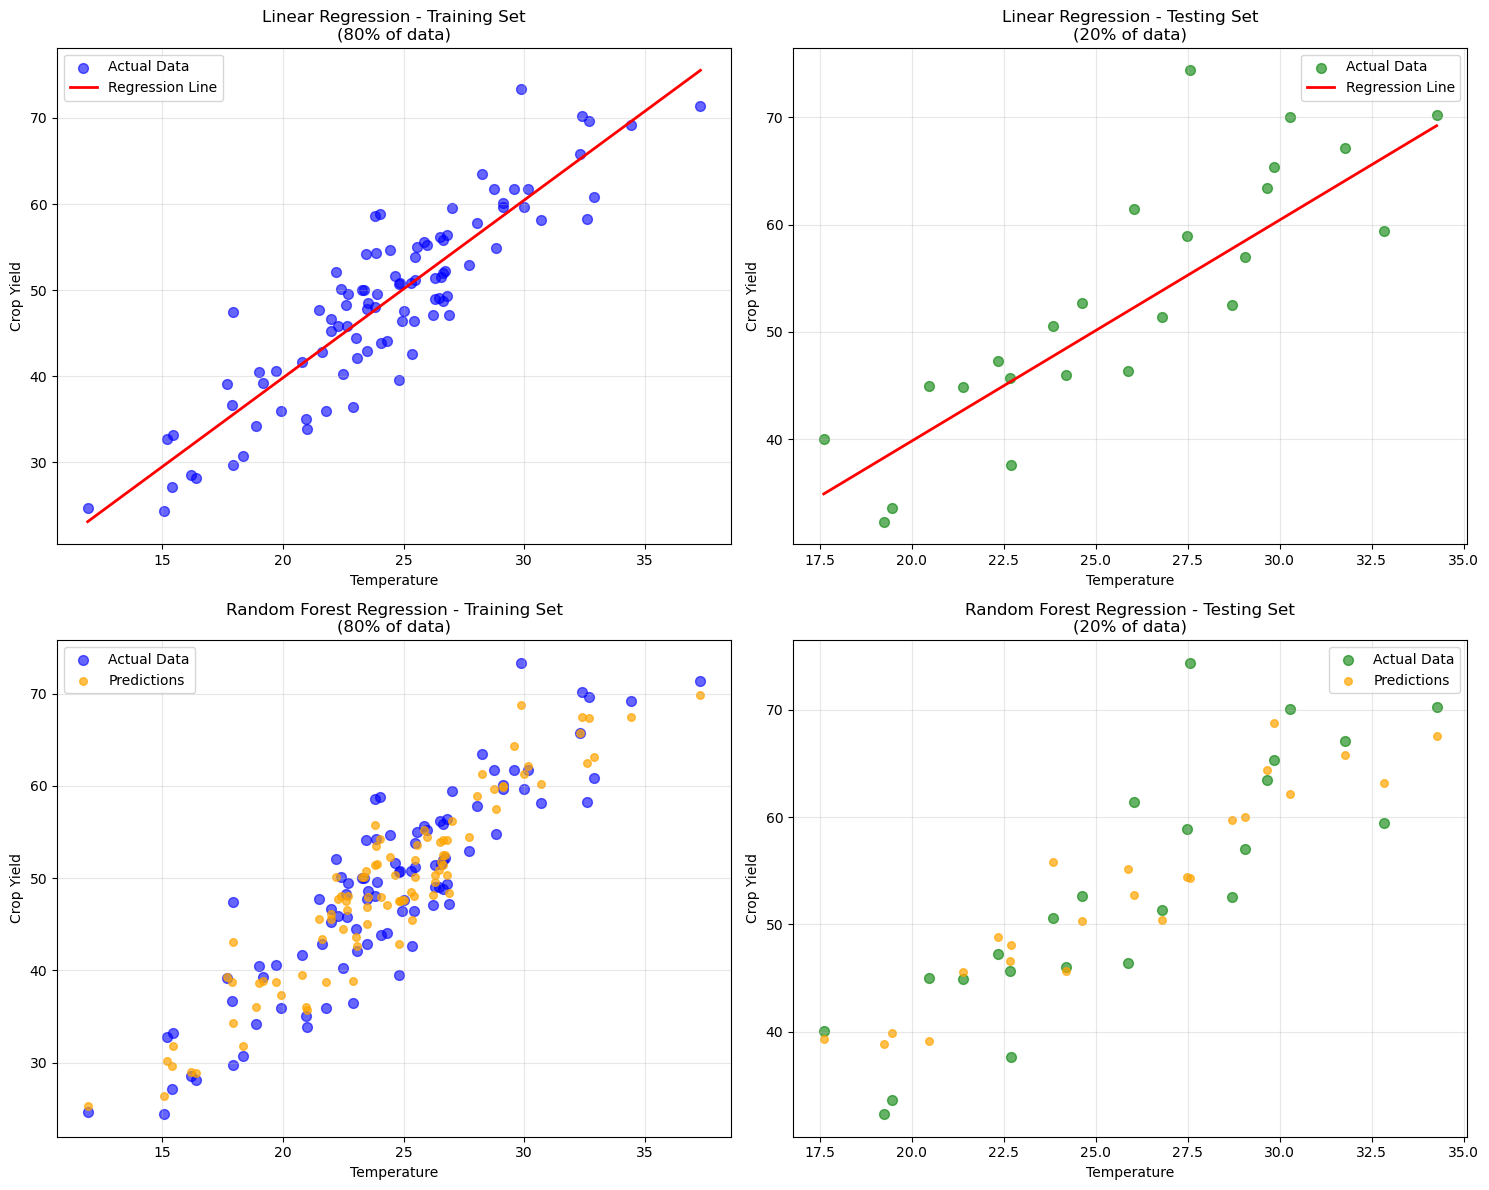

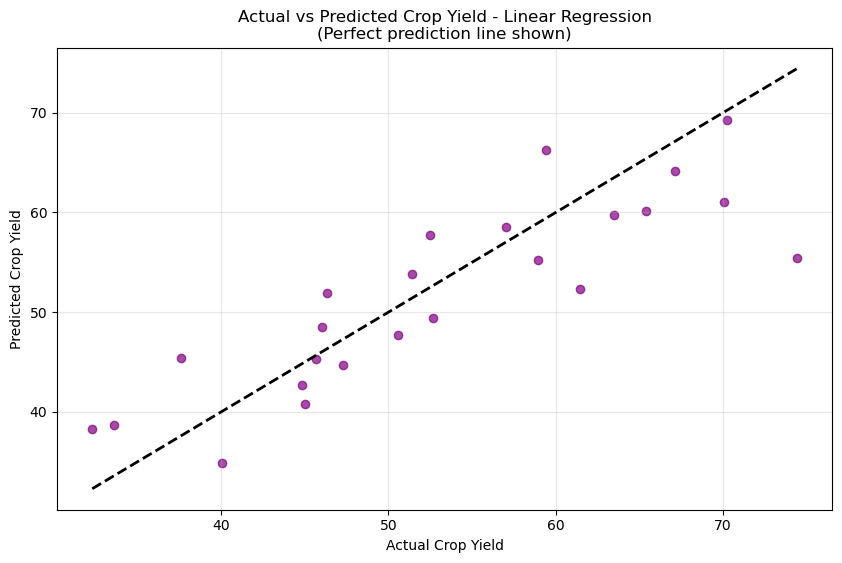

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Sort values for better plotting
sorted_idx_train = np.argsort(X_train.values.flatten())
sorted_idx_test = np.argsort(X_test.values.flatten())

X_train_sorted = X_train.iloc[sorted_idx_train]
y_train_sorted = y_train.iloc[sorted_idx_train]
lr_train_pred_sorted = lr_train_pred[sorted_idx_train]
rf_train_pred_sorted = rf_train_pred[sorted_idx_train]

X_test_sorted = X_test.iloc[sorted_idx_test]
y_test_sorted = y_test.iloc[sorted_idx_test]
lr_test_pred_sorted = lr_test_pred[sorted_idx_test]
rf_test_pred_sorted = rf_test_pred[sorted_idx_test]

# Plot 1: Linear Regression - Training Set
axes[0, 0].scatter(X_train_sorted, y_train_sorted, color='blue', alpha=0.6, label='Actual Data', s=50)
axes[0, 0].plot(X_train_sorted, lr_train_pred_sorted, color='red', linewidth=2, label='Regression Line')
axes[0, 0].set_title('Linear Regression - Training Set\n(80% of data)')
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('Crop Yield')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Linear Regression - Testing Set
axes[0, 1].scatter(X_test_sorted, y_test_sorted, color='green', alpha=0.6, label='Actual Data', s=50)
axes[0, 1].plot(X_test_sorted, lr_test_pred_sorted, color='red', linewidth=2, label='Regression Line')
axes[0, 1].set_title('Linear Regression - Testing Set\n(20% of data)')
axes[0, 1].set_xlabel('Temperature')
axes[0, 1].set_ylabel('Crop Yield')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Random Forest - Training Set
axes[1, 0].scatter(X_train_sorted, y_train_sorted, color='blue', alpha=0.6, label='Actual Data', s=50)
axes[1, 0].scatter(X_train_sorted, rf_train_pred_sorted, color='orange', alpha=0.7, label='Predictions', s=30)
axes[1, 0].set_title('Random Forest Regression - Training Set\n(80% of data)')
axes[1, 0].set_xlabel('Temperature')
axes[1, 0].set_ylabel('Crop Yield')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Random Forest - Testing Set
axes[1, 1].scatter(X_test_sorted, y_test_sorted, color='green', alpha=0.6, label='Actual Data', s=50)
axes[1, 1].scatter(X_test_sorted, rf_test_pred_sorted, color='orange', alpha=0.7, label='Predictions', s=30)
axes[1, 1].set_title('Random Forest Regression - Testing Set\n(20% of data)')
axes[1, 1].set_xlabel('Temperature')
axes[1, 1].set_ylabel('Crop Yield')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional visualization: Compare actual vs predicted for best model
plt.figure(figsize=(10, 6))

if best_model_name == "Linear Regression":
    best_pred = lr_test_pred
else:
    best_pred = rf_test_pred

plt.scatter(y_test, best_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Crop Yield')
plt.ylabel('Predicted Crop Yield')
plt.title(f'Actual vs Predicted Crop Yield - {best_model_name}\n(Perfect prediction line shown)')
plt.grid(True, alpha=0.3)
plt.show()